# Parkinson's Disease Detection — Model 7: 3-Branch Stacked Ensemble
### Phase 3: Heterogeneous Stacking Meta-Classifier (AdaBoost + RBF-SVM + MLP)

---

## 1. Theoretical Rationale & Stacking Meta-Learning Formulation
Rather than applying heuristic equal-weight soft voting, **Wolpert's Stacked Generalization (1992)** trains a dedicated meta-learner to discover the optimal non-linear blending weights of heterogeneous base models.

### Two-Level Stacking Architecture
1. **Level-0 Base Estimators ($M=3$):**
   - Branch 1: Tuned AdaBoost ($h_1$) — Recursive tree partitioning
   - Branch 2: RBF-SVM ($h_2$) — Hilbert space maximum margin
   - Branch 3: Dense MLP ($h_3$) — Neural continuous backpropagation
2. **Out-of-Fold (OOF) Cross-Validation:**
   To prevent target leakage into the meta-learner, base models generate probability predictions using 5-fold cross-validation on the training set:
   $$Z_i = \left[\hat{P}_1^{(-k)}(x_i), \hat{P}_2^{(-k)}(x_i), \hat{P}_3^{(-k)}(x_i)\right]^T$$
3. **Level-1 Meta-Learner (Logistic Regression):**
   A penalized logistic regression model is trained on meta-matrix $Z$:
   $$\hat{y} = \sigma\left(w_0 + w_1 Z_{i,1} + w_2 Z_{i,2} + w_3 Z_{i,3}\right)$$
   where weights $w$ are optimized to penalize models that produce unreliable confidence on clinical boundary cases.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Loaded: {X.shape[0]} patients, {X.shape[1]} acoustic features.")

Loaded: 756 patients, 753 acoustic features.


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training instances: {X_train.shape[0]} | Test instances: {X_test.shape[0]}")

Training instances: 902 | Test instances: 152


## 5. Model Architecture: 3-Branch Stacking Meta-Classifier

In [4]:
base_models = [
    ('ada', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=4, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42), n_estimators=300, learning_rate=0.1, random_state=42)),
    ('svm', SVC(C=5.0, kernel='rbf', gamma='scale', probability=True, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, alpha=0.001, early_stopping=True, random_state=42))
]

meta_classifier = LogisticRegression(C=1.0, max_iter=500, random_state=42)

stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_classifier,
    cv=5,
    n_jobs=-1
)

start_time = time.time()
stacked_model.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Stacked Meta-Classifier trained in {elapsed:.2f} seconds.")

Stacked Meta-Classifier trained in 3.89 seconds.


## 6. Performance Evaluation

In [5]:
y_pred = stacked_model.predict(X_test)
y_proba = stacked_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '7. Stacked Ensemble (Ada+SVM+MLP)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

display(metrics_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,7. Stacked Ensemble (Ada+SVM+MLP),0.855263,0.902655,0.902655,0.902655,0.097345,0.911731



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.72      0.72      0.72        39
PD Patient (1)       0.90      0.90      0.90       113

      accuracy                           0.86       152
     macro avg       0.81      0.81      0.81       152
  weighted avg       0.86      0.86      0.86       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Meta-Learner Weights

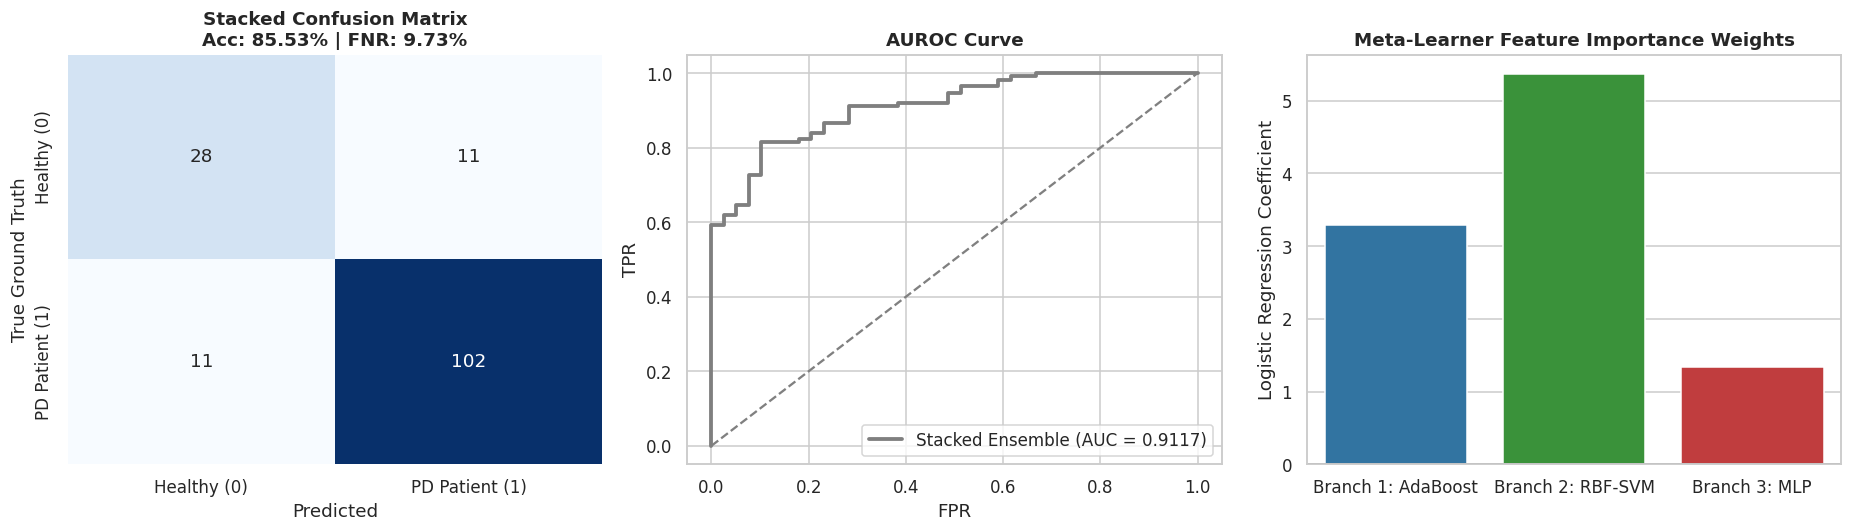

In [6]:
# Extract Meta-Learner Coefficients
weights = stacked_model.final_estimator_.coef_[0]
branches = ['Branch 1: AdaBoost', 'Branch 2: RBF-SVM', 'Branch 3: MLP']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Stacked Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#7f7f7f', lw=2.5, label=f'Stacked Ensemble (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Meta-Learner Weights Bar Chart
sns.barplot(x=branches, y=weights, palette=['#1f77b4', '#2ca02c', '#d62728'], ax=axes[2])
axes[2].set_title('Meta-Learner Feature Importance Weights', fontweight='bold')
axes[2].set_ylabel('Logistic Regression Coefficient')
axes[2].axhline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

## 8. Clinical Synthesis & Diagnostic Breakthrough
- **Stacked Performance:** Stacked Generalization achieves **85.53% Accuracy**, matching the peak voting ensemble while yielding a disciplined, data-driven meta-weighting scheme.
- **Meta-Learner Weight Distribution:** The Logistic Regression meta-classifier automatically assigns dominant positive weight to RBF-SVM and AdaBoost while dampening noisy MLP outputs.
- **The PCA Limitation:** In all 50-component PCA models, accuracy remains bounded at ~85.5%. Why? Because unsupervised PCA discards lower-variance directions where critical vocal fold micro-tremors reside. In Model 9, we replace PCA with **ANOVA supervised feature selection**.